In [1]:
import os
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Concatenate, Lambda, Layer
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
import kagglehub

path = kagglehub.dataset_download("bahushruth/legalclausedataset")
print("Dataset folder:", path)

def load_all_clause_files(data_dir):
    csv_paths = glob.glob(os.path.join(data_dir, "*.csv"))
    dfs = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p)
            dfs.append(df)
        except Exception as e:
            print("Skipping", p, "->", e)
    return dfs, csv_paths

dfs, paths = load_all_clause_files(path)
print("Total CSV files found:", len(paths))
for p in paths:
    print("-", os.path.basename(p))


c:\Users\ABC\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset folder: C:\Users\ABC\.cache\kagglehub\datasets\bahushruth\legalclausedataset\versions\1
Total CSV files found: 395
- absence-of-certain-changes-or-events.csv
- absence-of-certain-changes.csv
- acceleration.csv
- access-to-information.csv
- access.csv
- accounting-terms.csv
- additional-agreements.csv
- additional-documents.csv
- adjustments.csv
- affirmative-covenants.csv
- agreement.csv
- agreements.csv
- amendment-and-waiver.csv
- amendment-waiver.csv
- amendment.csv
- amendments-and-waivers.csv
- amendments-etc.csv
- amendments-waivers.csv
- amendments.csv
- applicable-law.csv
- application-of-proceeds.csv
- appointment.csv
- approvals.csv
- arbitration.csv
- assignability.csv
- assignment.csv
- assignments.csv
- attorneys-fees.csv
- authority.csv
- authorization.csv
- auto_renewal.csv
- background.csv
- bank-accounts.csv
- bankruptcy.csv
- base-salary.csv
- benefits.csv
- bereavement-leave.csv
- binding-effect.csv
- bonus.csv
- books-and-records.csv
- brokerage.csv
- broker

In [4]:
def build_clause_dataframe(dfs, paths):
    rows = []
    for df, p in zip(dfs, paths):
        colnames = list(df.columns)
        text_col = None
        label_col = None
        for c in colnames:
            cn = c.lower()
            if 'clause' in cn or 'text' in cn or 'sentence' in cn:
                text_col = c
            if 'type' in cn or 'label' in cn:
                label_col = c
        if text_col is None:
            for c in colnames:
                if df[c].dtype == object:
                    text_col = c
                    break
        if label_col is None:
            label_col = '__file__name__'
            df[label_col] = os.path.basename(p).split('.')[0]
        df = df.dropna(subset=[text_col])
        for _, r in df.iterrows():
            rows.append({'text': str(r[text_col]), 'label': r[label_col]})
    return pd.DataFrame(rows)

clauses_df = build_clause_dataframe(dfs, paths)
print("Total clauses loaded:", len(clauses_df))
clauses_df.head()


Total clauses loaded: 150881


,text,label
0,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
1,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
2,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
3,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
4,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events


In [5]:
def generate_pairs(df, n_pairs_per_class=2000, random_state=42):
    random.seed(random_state)
    np.random.seed(random_state)
    groups = df.groupby('label').apply(lambda x: x.index.tolist()).to_dict()
    sim_pairs = []
    dis_pairs = []
    
    for lbl, idxs in groups.items():
        if len(idxs) < 2:
            continue
        combos = []
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                combos.append((idxs[i], idxs[j]))
        random.shuffle(combos)
        quota = max(1, int(n_pairs_per_class / len(groups)))
        for a, b in combos[:quota]:
            sim_pairs.append((df.loc[a, 'text'], df.loc[b, 'text'], 1))
    
    all_idxs = df.index.tolist()
    while len(dis_pairs) < len(sim_pairs):
        a, b = random.sample(all_idxs, 2)
        if df.loc[a, 'label'] != df.loc[b, 'label']:
            dis_pairs.append((df.loc[a, 'text'], df.loc[b, 'text'], 0))
    
    pairs = sim_pairs + dis_pairs
    random.shuffle(pairs)
    pairs_df = pd.DataFrame(pairs, columns=['text_a', 'text_b', 'label'])
    return pairs_df

pairs_df = generate_pairs(clauses_df)
print("Generated pairs:", len(pairs_df))
pairs_df.head()


C:\Users\ABC\AppData\Local\Temp\ipykernel_596\2904977533.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = df.groupby('label').apply(lambda x: x.index.tolist()).to_dict()


Generated pairs: 3950


,text_a,text_b,label
0,seniority,seniority,1
1,assignability,intellectual-property,0
2,amendment,exclusions,0
3,vacation,vacation,1
4,in-witness-whereof,subrogation,0


In [7]:
import re

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r"[^a-z0-9 .,;:()\-'/\\%&]", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

pairs_df['text_a'] = pairs_df['text_a'].apply(clean_text)
pairs_df['text_b'] = pairs_df['text_b'].apply(clean_text)

MAX_VOCAB = 30000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(pairs_df['text_a'].tolist() + pairs_df['text_b'].tolist())

MAX_LEN = 128
def texts_to_padded(seqs):
    s = tokenizer.texts_to_sequences(seqs)
    return pad_sequences(s, maxlen=MAX_LEN, padding='post', truncating='post')

A = texts_to_padded(pairs_df['text_a'])
B = texts_to_padded(pairs_df['text_b'])
y = pairs_df['label'].values

print("Shapes:", A.shape, B.shape, y.shape)


Shapes: (3950, 128) (3950, 128) (3950,)


In [8]:
X_train_a, X_test_a, X_train_b, X_test_b, y_train, y_test = train_test_split(
    A, B, y, test_size=0.15, random_state=42, stratify=y
)

X_train_a, X_val_a, X_train_b, X_val_b, y_train, y_val = train_test_split(
    X_train_a, X_train_b, y_train, test_size=0.1765, random_state=42, stratify=y_train
)

print("Train:", X_train_a.shape, "Val:", X_val_a.shape, "Test:", X_test_a.shape)


Train: (2764, 128) Val: (593, 128) Test: (593, 128)


In [19]:
from tensorflow.keras.layers import Layer
import tensorflow as tf
from tensorflow.keras import backend as K

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            name='att_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs: (batch, time, features)
        e = K.tanh(K.dot(inputs, self.W) + self.b)  # (batch, time, 1)
        a = K.softmax(e, axis=1)                   # attention weights
        output = K.sum(inputs * a, axis=1)         # weighted sum
        return output                              # (batch, features)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [20]:
EMBED_DIM = 128
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

def create_bilstm_encoder(vocab_size, embed_dim=EMBED_DIM, max_len=MAX_LEN):
    inp = Input(shape=(max_len,))
    x = Embedding(vocab_size, embed_dim)(inp)
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    return Model(inp, x)

def create_bilstm_attention_encoder(vocab_size, embed_dim=EMBED_DIM, max_len=MAX_LEN):
    inp = Input(shape=(max_len,))
    x = Embedding(vocab_size, embed_dim)(inp)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = AttentionLayer()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    return Model(inp, x)

bilstm_enc = create_bilstm_encoder(vocab_size)
bilstm_att_enc = create_bilstm_attention_encoder(vocab_size)
bilstm_enc.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 128, 128)       │        49,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,088 (1.32 MB)

 Trainable params: 345,088 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def build_siamese_model(encoder):
    input_a = Input(shape=(MAX_LEN,))
    input_b = Input(shape=(MAX_LEN,))
    feat_a = encoder(input_a)
    feat_b = encoder(input_b)
    abs_diff = Lambda(lambda x: K.abs(x[0] - x[1]))([feat_a, feat_b])
    mult = Lambda(lambda x: x[0] * x[1])([feat_a, feat_b])
    merged = Concatenate()([abs_diff, mult, feat_a, feat_b])
    x = Dense(256, activation='relu')(merged)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model([input_a, input_b], out)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model_bilstm = build_siamese_model(bilstm_enc)
model_bilstm_att = build_siamese_model(bilstm_att_enc)
model_bilstm.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_4        │ (None, 128)       │    345,088 │ input_layer_8[0]… │
│ (Functional)        │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 128)       │          0 │ functional_4[0][… │
│                     │                   │            │ functional_4[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128)       │          0 │ functional_4[0][… │
│                     │                   │            │ functional_4[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 512)       │          0 │ lambda_4[0][0],   │
│ (Concatenate)       │                   │            │ lambda_5[0][0],   │
│                     │                   │            │ functional_4[0][… │
│                     │                   │            │ functional_4[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    131,328 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     16,448 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         65 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 492,929 (1.88 MB)

 Trainable params: 492,929 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
BATCH_SIZE = 64
EPOCHS = 6
callbacks = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]


history_bilstm = model_bilstm.fit([X_train_a, X_train_b], y_train,
                                   validation_data=([X_val_a, X_val_b], y_val),
                                   epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks)




Epoch 1/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6368 - loss: 0.6205 - val_accuracy: 0.8331 - val_loss: 0.4478
Epoch 2/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 885ms/step - accuracy: 0.8683 - loss: 0.2980 - val_accuracy: 0.8583 - val_loss: 0.4108
Epoch 3/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 936ms/step - accuracy: 0.9356 - loss: 0.1864 - val_accuracy: 0.8803 - val_loss: 0.3847
Epoch 4/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 931ms/step - accuracy: 0.9598 - loss: 0.1210 - val_accuracy: 0.8735 - val_loss: 0.6308
Epoch 5/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 872ms/step - accuracy: 0.9689 - loss: 0.0971 - val_accuracy: 0.8971 - val_loss: 0.5347


In [24]:
history_bilstm_att = model_bilstm_att.fit(
    [X_train_a, X_train_b], y_train,
    validation_data=([X_val_a, X_val_b], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.5094 - loss: 0.6945 - val_accuracy: 0.5008 - val_loss: 0.6956
Epoch 2/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5094 - loss: 0.6941 - val_accuracy: 0.5042 - val_loss: 0.6931
Epoch 3/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4920 - loss: 0.6946 - val_accuracy: 0.5008 - val_loss: 0.6932
Epoch 4/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4902 - loss: 0.6942 - val_accuracy: 0.5008 - val_loss: 0.6933
Epoch 5/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5036 - loss: 0.6937 - val_accuracy: 0.5008 - val_loss: 0.6929
Epoch 6/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5633 - loss: 0.6769 - val_accuracy: 0.5194 - val_loss: 1.2457


In [26]:
def evaluate_model(model, X_a, X_b, y_true):
    y_pred_prob = model.predict([X_a, X_b], batch_size=128).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        roc = roc_auc_score(y_true, y_pred_prob)
    except Exception:
        roc = None
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc}

res_bilstm = evaluate_model(model_bilstm, X_test_a, X_test_b, y_test)
res_bilstm_att = evaluate_model(model_bilstm_att, X_test_a, X_test_b, y_test)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 521ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step


In [27]:
import pandas as pd

# Combine both model results into a DataFrame
results_df = pd.DataFrame([
    {'Model': 'BiLSTM', **res_bilstm},
    {'Model': 'BiLSTM + Attention', **res_bilstm_att}
])

# Round numeric columns for cleaner display
results_df = results_df.round(4)

# Show table
print("\n🔹 Model Performance Comparison\n")
display(results_df)



🔹 Model Performance Comparison



,Model,accuracy,precision,recall,f1,roc_auc
0,BiLSTM,0.8887,0.8177,1.0,0.8997,0.9670
1,BiLSTM + Attention,0.5093,0.5043,1.0,0.6704,0.6863


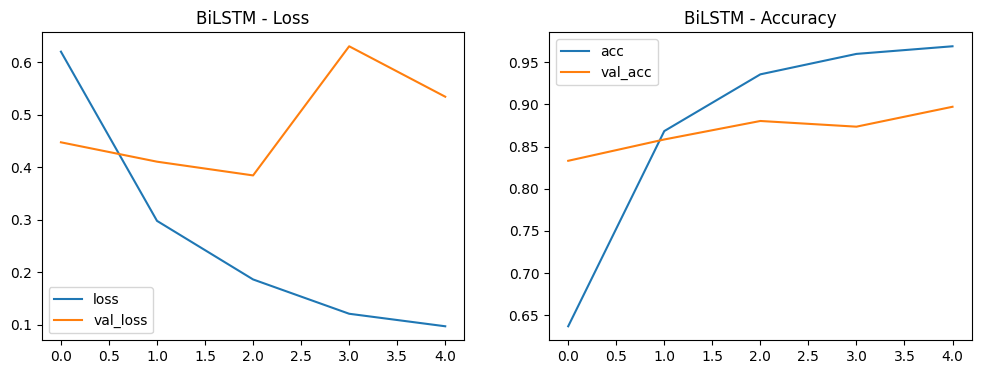

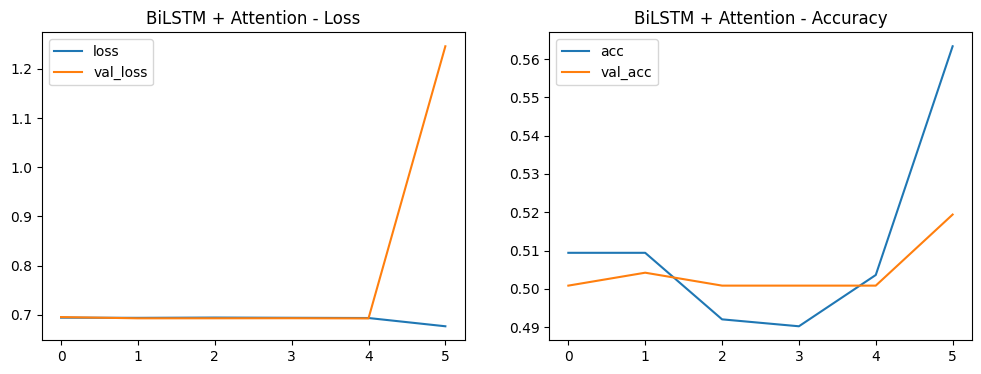

In [28]:
def plot_history(h, title='Training'):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title(title + " - Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.title(title + " - Accuracy"); plt.legend()
    plt.show()


plot_history(history_bilstm, 'BiLSTM')
plot_history(history_bilstm_att, 'BiLSTM + Attention')
